Homework 3 - Hydrodynamics

we study burger equation (catastrophe theory) via euler method, 
varying the viscosities (3 values), 
varying initial conditions (4 cases).
every time evolution is plotted at 5/6 different times.

In [34]:
import numpy as np
import matplotlib.pyplot as plt

In [35]:
# Parametri della simulazione
L = 100.0         # Lunghezza del dominio [0,1]
Nx = 100        # Numero di punti spaziali
dx = L / Nx     # Passo spaziale
dt = 0.01      # Passo temporale

# Diversi valori della viscosità ν
viscosities = [0.1,1,20]  # Bassa, media e alta viscosità

# Diversi valori del tempo
times = [0,8,16,24,32]  

In [36]:
def f_initial(x):
    return  np.exp( - x**2 / 100)

In [37]:
# Funzione per risolvere l'equazione di Burgers
def solve_burgers(nu, f_initial,T):
    Nt = int(T / dt)  # Numero di passi temporali
    x = np.linspace(-L/2, L/2, Nx)
    phi = f_initial(x)  # Condizione iniziale

    for _ in range(Nt):
        phi_new = np.copy(phi)
        
        phi_new[0] = (phi_new[-1] + phi_new[0])/2  # Periodic boundary condition
        phi_new[-1] = phi_new[0]
        
        for i in range(1, Nx-1):  # Differenze finite centrali
            adv = phi[i] * (phi[i+1] - phi[i-1]) / (2*dx)  # Termine convettivo
            diff = nu * (phi[i+1] - 2*phi[i] + phi[i-1]) / dx**2  # Termine diffusivo
            phi_new[i] = phi[i] - dt * adv + dt * diff  # Aggiornamento esplicito

        phi = np.copy(phi_new)
    
    return x, phi

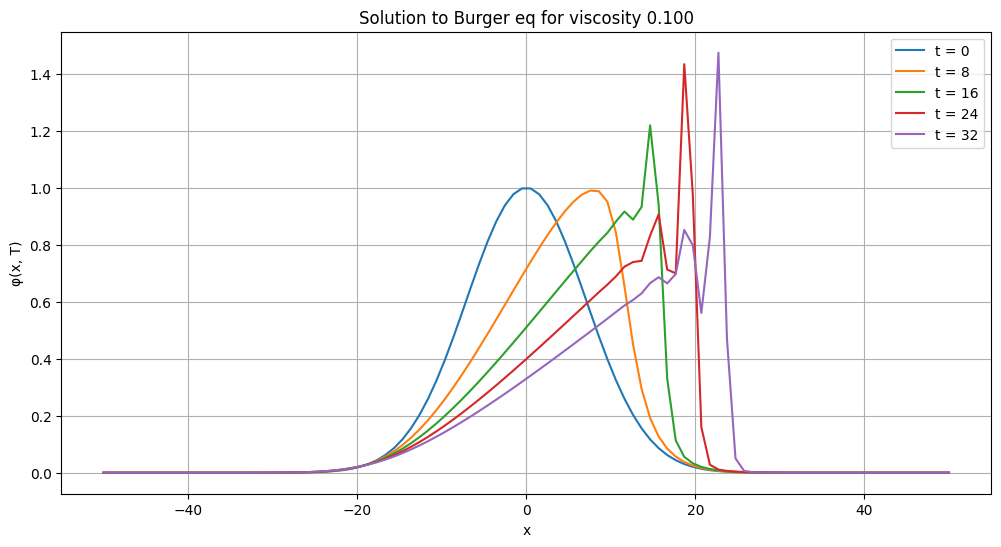

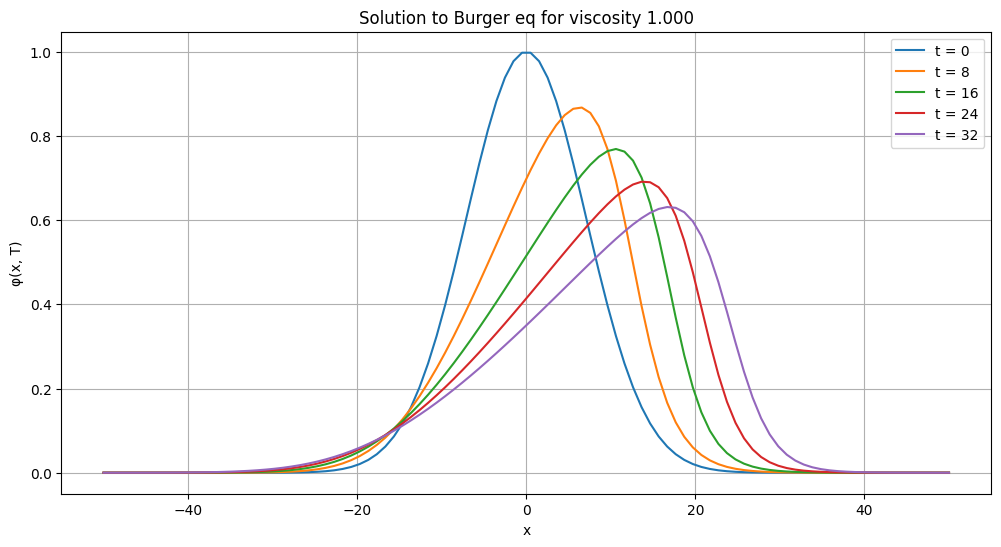

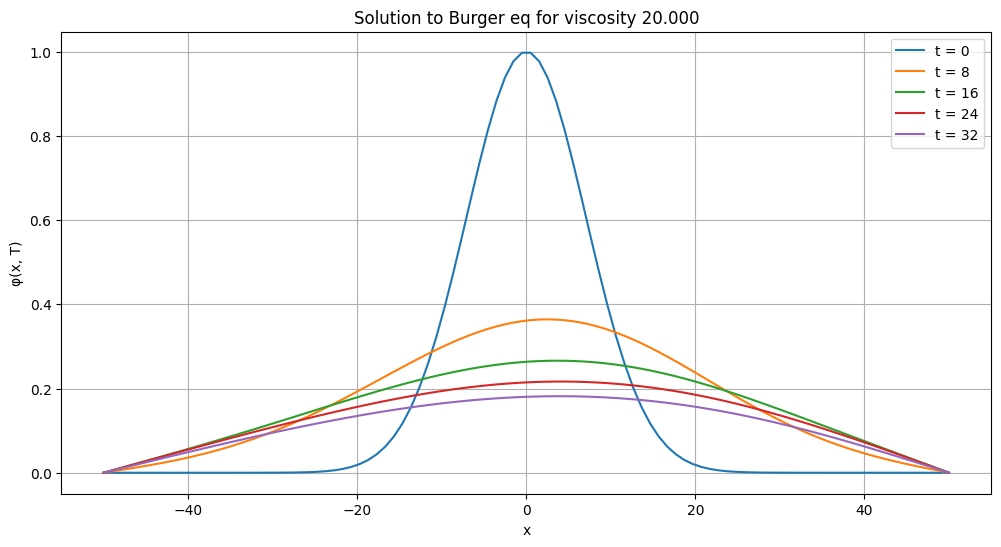

In [38]:
# Risoluzione per diversi valori di viscosità
#plt.figure(figsize=(12, 6))    

for nu in viscosities:
    plt.figure(figsize=(12, 6)) 
    for t in times:
        x, phi_final = solve_burgers(nu,f_initial,t)
        plt.plot(x, phi_final, label=f"t = {t}")
    
    # Grafico del risultato
    plt.xlabel("x")
    plt.ylabel("φ(x, T)")
    plt.title("Solution to Burger eq for viscosity %1.3f" %nu)
    plt.legend()
    plt.grid()
    plt.show()

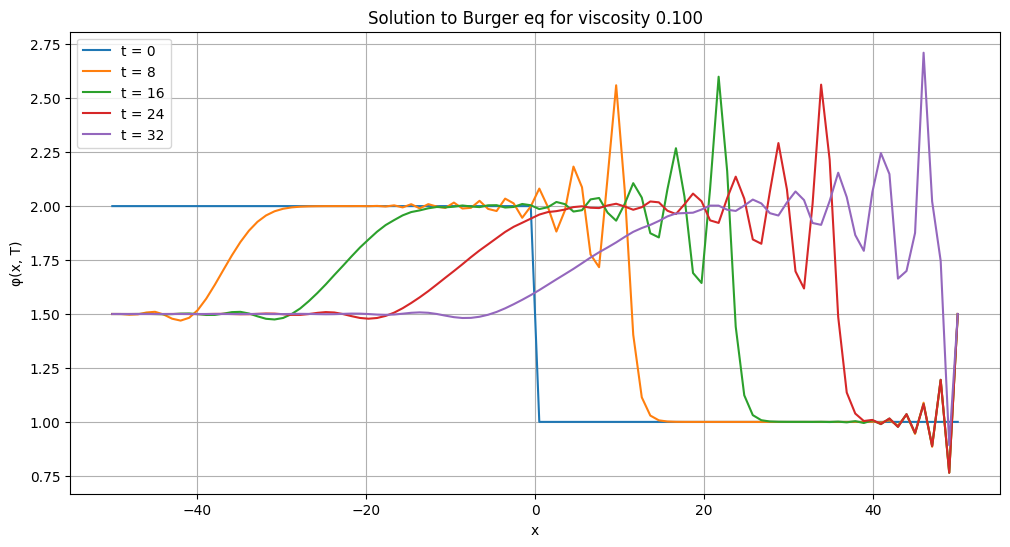

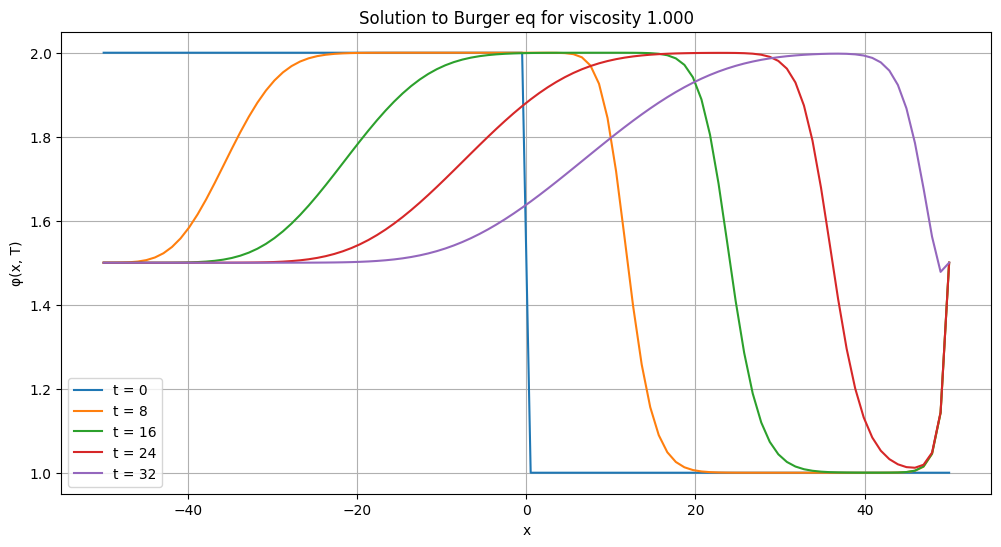

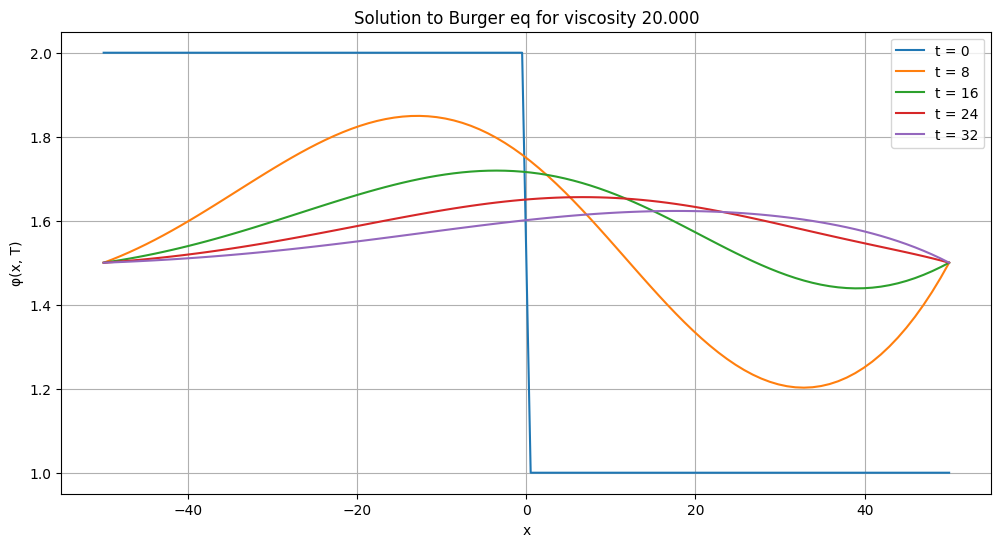

In [39]:
def f_initial(x):
    y = np.ones_like(x)
    for i in range(int(Nx/2)):
        y[i] += 1
    return  y

for nu in viscosities:
    plt.figure(figsize=(12, 6)) 
    for t in times:
        x, phi_final = solve_burgers(nu,f_initial,t)
        plt.plot(x, phi_final, label=f"t = {t}")
    
    # Grafico del risultato
    plt.xlabel("x")
    plt.ylabel("φ(x, T)")
    plt.title("Solution to Burger eq for viscosity %1.3f" %nu)
    plt.legend()
    plt.grid()
    plt.show()

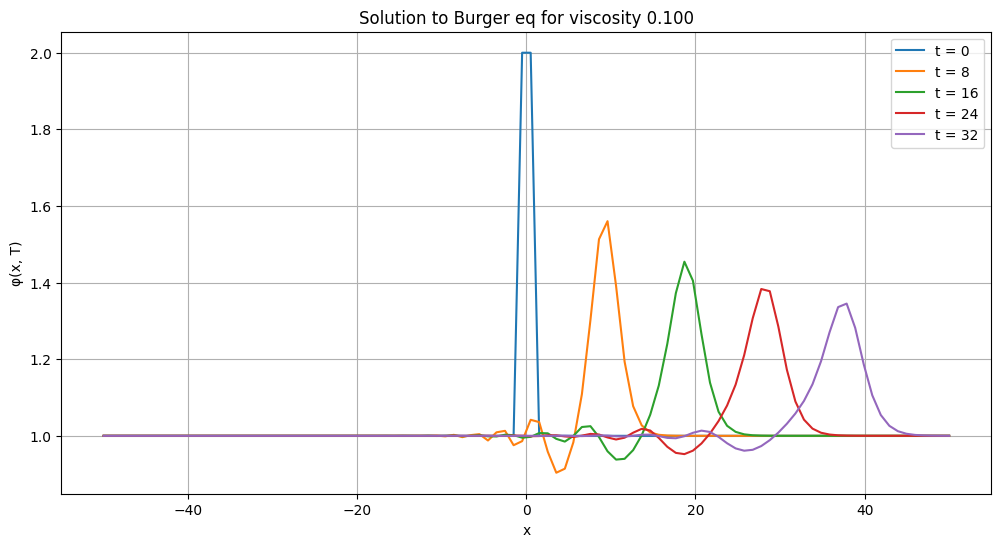

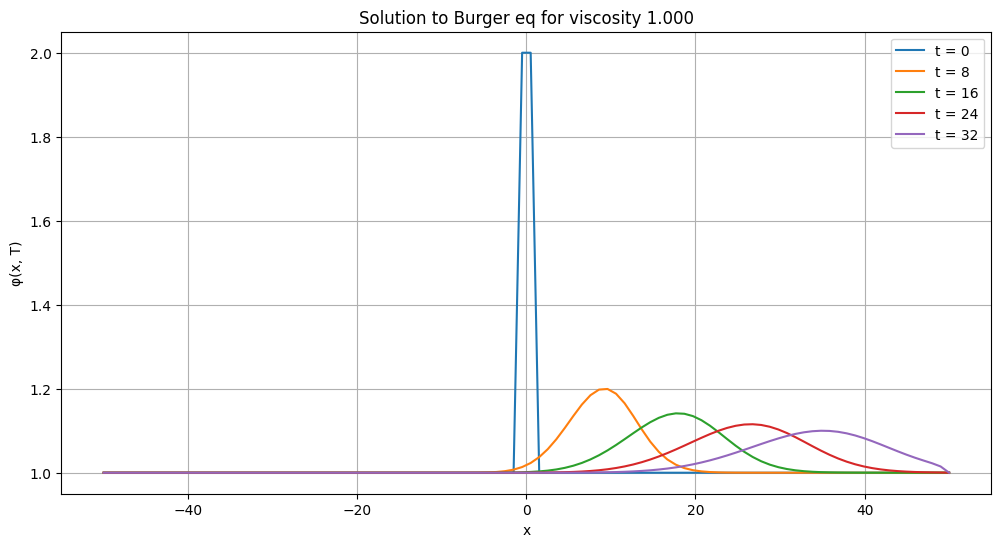

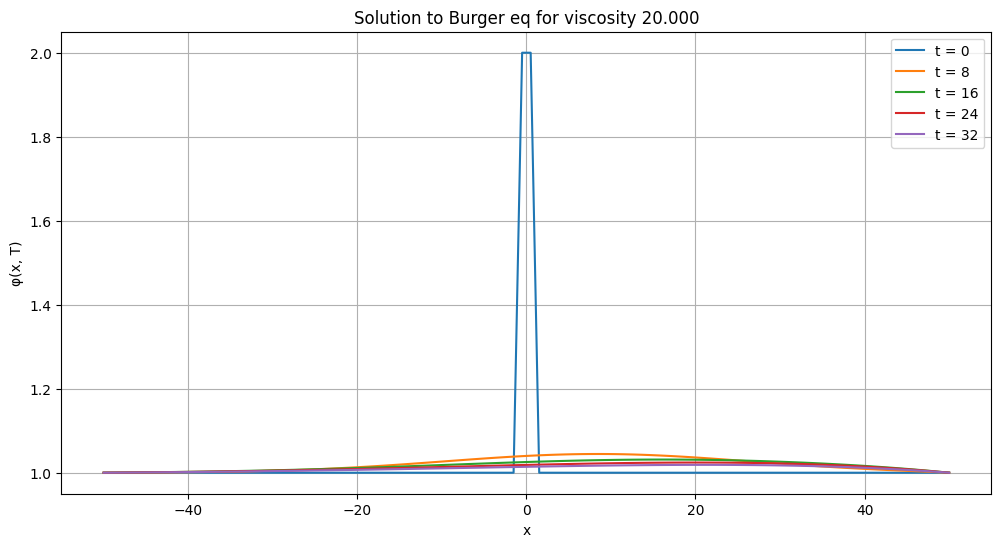

In [40]:
def f_initial(x):
    y = np.ones_like(x)
    for i in range(Nx):
        if abs(x[i]) <= 1:
            y[i] += 1
    return  y

for nu in viscosities:
    plt.figure(figsize=(12, 6)) 
    for t in times:
        x, phi_final = solve_burgers(nu,f_initial,t)
        plt.plot(x, phi_final, label=f"t = {t}")
    
    # Grafico del risultato
    plt.xlabel("x")
    plt.ylabel("φ(x, T)")
    plt.title("Solution to Burger eq for viscosity %1.3f" %nu)
    plt.legend()
    plt.grid()
    plt.show()

In [64]:
# Parametri della simulazione
L = 5.0         # Lunghezza del dominio [0,1]
Nx = 100        # Numero di punti spaziali
dx = L / Nx     # Passo spaziale
dt = 0.001      # Passo temporale

# Diversi valori della viscosità ν
viscosities = [0.1,0.2,0.3,1]  # Bassa, media e alta viscosità

# Diversi valori del tempo
times = [0,0.1,0.25,0.5,0.75,1]   

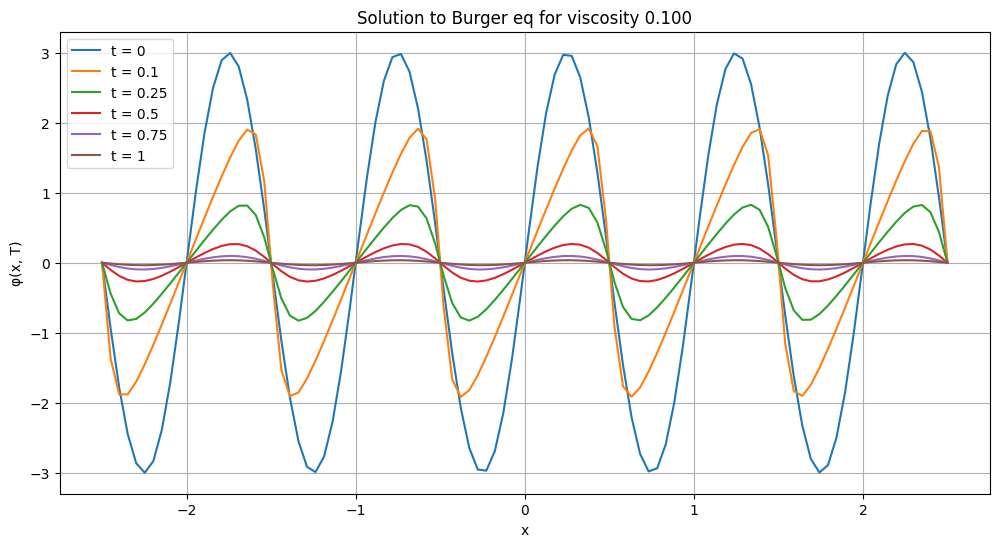

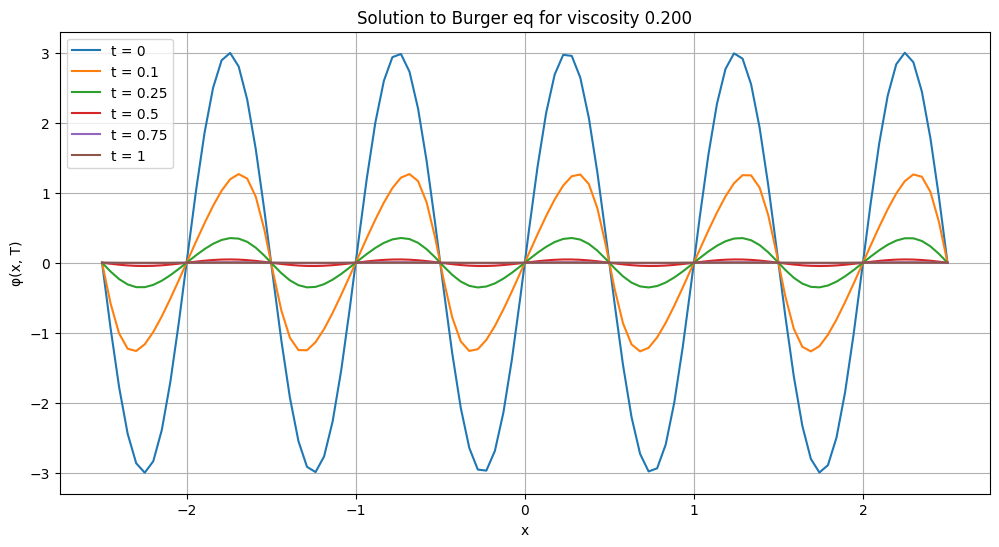

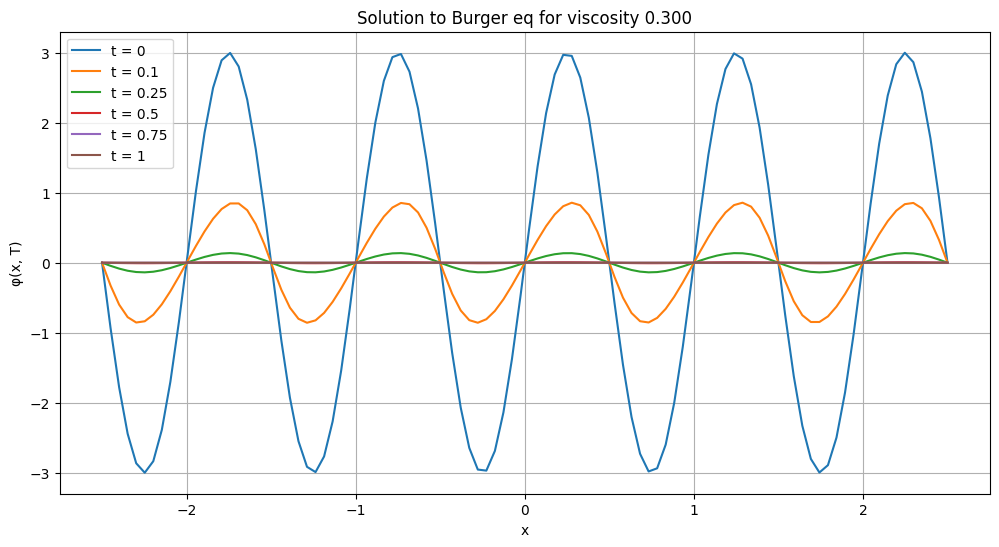

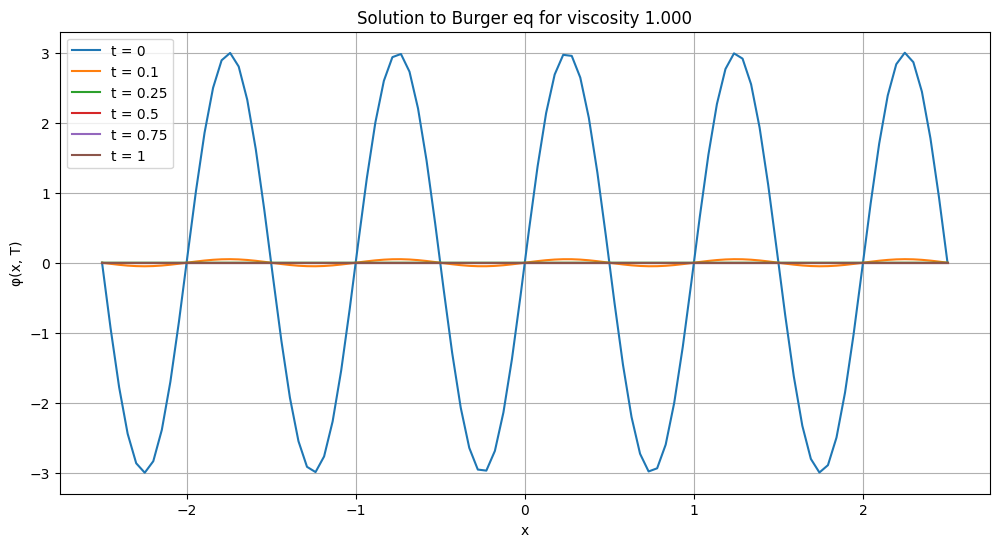

In [65]:
def f_initial(x):
    return 3 * np.sin(2 * np.pi * x)

for nu in viscosities:
    plt.figure(figsize=(12, 6)) 
    for t in times:
        x, phi_final = solve_burgers(nu,f_initial,t)
        plt.plot(x, phi_final, label=f"t = {t}")
    
    # Grafico del risultato
    plt.xlabel("x")
    plt.ylabel("φ(x, T)")
    plt.title("Solution to Burger eq for viscosity %1.3f" %nu)
    plt.legend()
    plt.grid()
    plt.show()